In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    confusion_matrix,
    precision_recall_curve
)

from pathlib import Path
import sys


PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [ ]:
train_df = pd.read_csv(PROJECT_ROOT / "Data Understanding, Exploration & Feature Engineering/Dataset & Feature Engineered data/train.csv")
test_df  = pd.read_csv(PROJECT_ROOT / "Data Understanding, Exploration & Feature Engineering/Dataset & Feature Engineered data/test.csv")

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)

Train shape: (239756, 22)
Test shape:  (59939, 22)


In [ ]:
# Splitting the data into X (features) and y (target)
target_col = "is_fraud"
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col].astype(int)

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col].astype(int)

print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape,  "y_test shape: ", y_test.shape)

X_train shape: (239756, 21) y_train shape: (239756,)
X_test shape:  (59939, 21) y_test shape:  (59939,)


In [ ]:
categorical_features = ["country", "bin_country", "merchant_category"]
numeric_features = [col for col in X_train.columns if col not in categorical_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['account_age_days', 'total_transactions_user', 'amount', 'avs_match', 'cvv_result', 'three_ds_flag', 'shipping_distance_km', 'evening', 'weekend', 'channel', 'time_day_sin', 'time_day_cos', 'time_month_sin', 'time_month_cos', 'time_wd_sin', 'time_wd_cos', 'time_hour_sin', 'time_hour_cos']
Categorical features: ['country', 'bin_country', 'merchant_category']


In [ ]:
# Data Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(
            drop = "first",
            handle_unknown = "ignore",
            sparse_output = False
        ), categorical_features)
    ],
    remainder="drop"
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape: ", X_test_processed.shape)

num_feature_names = numeric_features
cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
feature_names = np.concatenate([num_feature_names, cat_feature_names])
print("Total model features:", len(feature_names))


Processed X_train shape: (239756, 40)
Processed X_test shape:  (59939, 40)
Total model features: 40


In [ ]:
# Trimmed mean aggregation function
def trimmed_mean_agg_k(prob_matrix: np.ndarray, k: int = 1):
    n_models = prob_matrix.shape[0]
    if (2 * k) >= n_models:
        return prob_matrix.mean(axis = 0)
    sorted_probs = np.sort(prob_matrix, axis = 0)
    return sorted_probs[k:n_models - k, :].mean(axis=0)


In [ ]:
# Defining the base models
base_models = {
    "logreg": LogisticRegression(
        max_iter = 1000,
        class_weight = "balanced",
        random_state = 42
    ),
    "knn": KNeighborsClassifier(
        n_neighbors = 15
    ),
    "rf": RandomForestClassifier(
        n_estimators = 300,
        random_state = 42,
        n_jobs = -1,
        class_weight = "balanced_subsample"
    ),
    "gnb": GaussianNB()
}


In [ ]:
model_probs = {}
pipelines = {}

for name, model in base_models.items():
    pipe = Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe

    # probabilities for fraud (class 1)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    model_probs[name] = y_prob

    print(f"{name} done. Prob range: [{y_prob.min():.4f}, {y_prob.max():.4f}]")


logreg done. Prob range: [0.0040, 1.0000]
knn done. Prob range: [0.0000, 1.0000]
rf done. Prob range: [0.0000, 0.9867]
gnb done. Prob range: [0.0000, 1.0000]


In [ ]:
# Creating ensemble probability and prediction
prob_matrix = np.vstack([model_probs[name] for name in base_models.keys()])
y_prob_ensemble = trimmed_mean_agg_k(prob_matrix, k=1)

threshold = 0.5
y_pred_ensemble = (y_prob_ensemble >= threshold).astype(int)

print("Ensemble probability range:", y_prob_ensemble.min(), y_prob_ensemble.max())


Ensemble probability range: 1.6712860737940693e-07 0.9999959693764191


In [ ]:
# Evaluation
report = classification_report(y_test, y_pred_ensemble, output_dict=True)
roc_auc = roc_auc_score(y_test, y_prob_ensemble)
avg_precision = average_precision_score(y_test, y_prob_ensemble)

fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob_ensemble)
cm = confusion_matrix(y_test, y_pred_ensemble)
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob_ensemble)

print("Baseline (Trimmed Mean) ROC-AUC:", roc_auc)
print("Baseline (Trimmed Mean) PR-AUC:", avg_precision)
print("Confusion Matrix:\n", cm)


Baseline (Trimmed Mean) ROC-AUC: 0.9595816190523899
Baseline (Trimmed Mean) PR-AUC: 0.6723666331100968
Confusion Matrix:
 [[57794   823]
 [  452   870]]


In [ ]:
results = {
    "model": "Trimmed Mean Aggregation Baseline Ensemble",
    "classification_report": report,
    "roc_auc": roc_auc,
    "average_precision": avg_precision,
    "confusion_matrix": {
        "labels": ["non_fraud", "fraud"],
        "matrix": cm.tolist()
    },
    "roc_curve": {
        "fpr": fpr.tolist(),
        "tpr": tpr.tolist(),
        "thresholds": roc_thresholds.tolist()
    },
    "precision_recall_curve": {
        "precision": precision.tolist(),
        "recall": recall.tolist(),
        "thresholds": pr_thresholds.tolist()
    }
}

json_path = "results/baseline_trimmed_mean_results.json"
with open(json_path, "w") as f:
    json.dump(results, f, indent=4)

print(f"Saved: {json_path}")


Saved: baseline_trimmed_mean_results.json


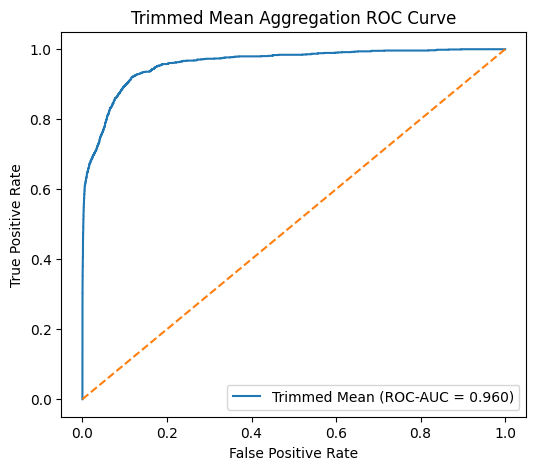

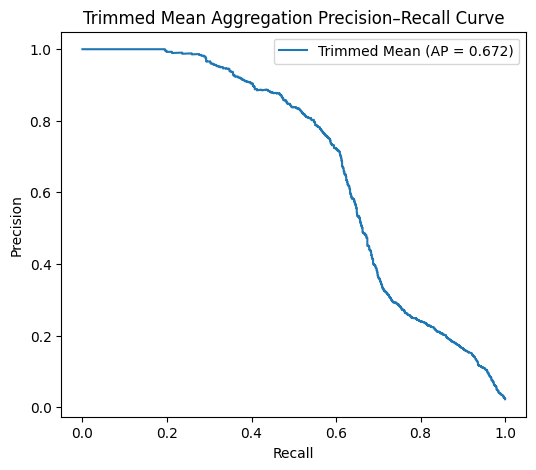

In [ ]:
# ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Trimmed Mean (ROC-AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Trimmed Mean Aggregation ROC Curve")
plt.legend()
plt.show()

# Precision/Recall Curve
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"Trimmed Mean (AP = {avg_precision:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Trimmed Mean Aggregation Precision–Recall Curve")
plt.legend()
plt.show()